In [2]:
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON
import matplotlib.pyplot as plt

In [1]:
## Get the number of occurence of each type of sample (the number of environmental, human and animal samples)

sparqlQuery = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX sosa: <http://www.w3.org/ns/sosa/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ncit: <http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl>
PREFIX aro: <http://purl.obolibrary.org/obo/ARO_>
PREFIX sio: <http://semanticscience.org/resource/>
PREFIX prov: <http://www.w3.org/ns/prov#>

SELECT ?sampleTypeLabel (COUNT(*) AS ?count)
FROM <http://www.ontotext.com/explicit>
WHERE {
    ?sample sio:000068 ?sampleType .
    ?sampleType rdfs:label ?sampleTypeLabel .
}
GROUP BY ?sampleTypeLabel
ORDER BY DESC(?count)
"""

In [3]:
## Defining a data structure for the plot
data = {
    "sample_type_label": [],
    "count": []
}

## Perform the sparql queryd
## Requires the sparql endpoint to be launched at http://localhost:7201

sparql = SPARQLWrapper("http://localhost:8081/graphdb/repositories/abromics-kg")
sparql.setReturnFormat(JSON)
sparql.setQuery(sparqlQuery)
try:
    res = sparql.query().convert()
    recs = res["results"]["bindings"]
    for item in recs:
        data["sample_type_label"].append(item["sampleTypeLabel"]["value"])
        data["count"].append(int(item["count"]["value"]))
except Exception as e:
    print(e)

In [4]:
df = pd.DataFrame(data)
df

,sample_type_label,count
0,animal,60
1,environmental,43
2,human,7


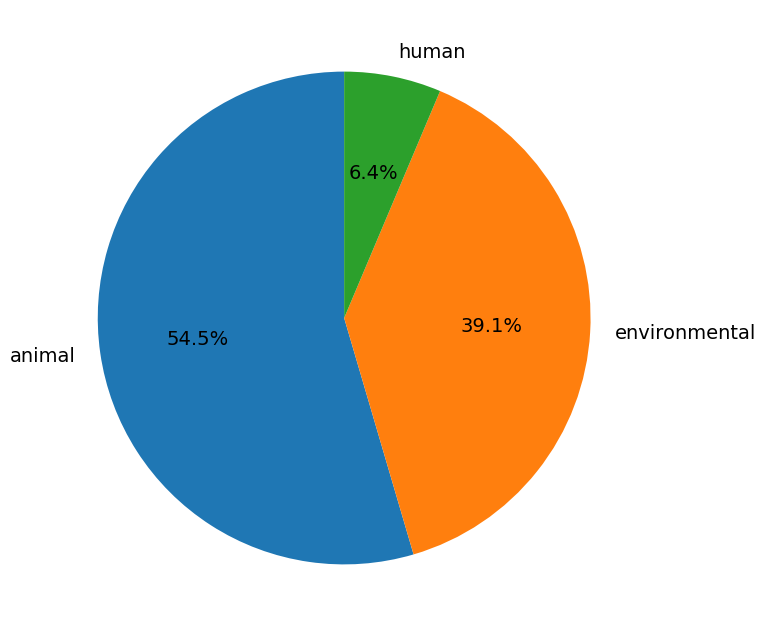

In [10]:
plt.figure(figsize=(8, 8))
plt.pie(
    df["count"],
    labels=df["sample_type_label"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={'fontsize': 14}
)
plt.savefig("figure-2b.pdf", dpi=450)
plt.show()